# RNA para Clasificación con Iris

Demo simple de red neuronal artificial en Keras para clasificar especies de flores.


## 1. Importar librerías


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, f1_score

from tensorflow import keras
from tensorflow.keras import layers

## 2. Cargar dataset
El dataset Iris tiene 3 clases: setosa, versicolor y virginica.


In [2]:
data = load_iris()
X = data.data
y = data.target

print("Forma de X:", X.shape)
print("Clases:", data.target_names)
print("Primeras 5 etiquetas:", y[:5])

Forma de X: (150, 4)
Clases: ['setosa' 'versicolor' 'virginica']
Primeras 5 etiquetas: [0 0 0 0 0]


## 3. Separar entrenamiento y validación
Usamos `stratify=y` para conservar la proporción de clases.


In [3]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Entrenamiento:", X_train.shape, y_train.shape)
print("Validación:", X_val.shape, y_val.shape)

Entrenamiento: (120, 4) (120,)
Validación: (30, 4) (30,)


## 4. Estandarizar variables


In [4]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

## 5. Crear la red neuronal
Como es clasificación multiclase, la salida tiene 3 neuronas con `softmax`.


In [5]:
model = keras.Sequential([
    keras.Input(shape=(X_train.shape[1],)), #Le dice a la red cuántos datos recibirá por cada ejemplo
    layers.Dense(16, activation="relu"),  #Es una capa oculta con 16 neuronas. Es el "filtro" que decide qué información pasa
    layers.Dense(8, activation="relu"),  #Sirve para que la red extraiga patrones más específicos de los datos.
    layers.Dense(3, activation="softmax")]) #clasificar entre 3 categorías diferentes. "softmax" convierte la salida en probabilidades.

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 243 (972.00 B)

 Trainable params: 243 (972.00 B)

 Non-trainable params: 0 (0.00 B)

## 6. Compilar modelo


In [6]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

## 7. Entrenar modelo


In [7]:
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=16, #El modelo mira los datos en grupos pequeños (de 16 en 16).
    validation_data=(X_val, y_val), #el modelo se prueba con datos que no ha visto antes (X_val)
    verbose=1)  #Ver la barra de progreso

Epoch 1/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.3167 - loss: 1.2715 - val_accuracy: 0.4667 - val_loss: 1.2275
Epoch 2/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3250 - loss: 1.1816 - val_accuracy: 0.4667 - val_loss: 1.1480
Epoch 3/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3833 - loss: 1.1165 - val_accuracy: 0.5000 - val_loss: 1.0910
Epoch 4/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5417 - loss: 1.0634 - val_accuracy: 0.6333 - val_loss: 1.0478
Epoch 5/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6250 - loss: 1.0222 - val_accuracy: 0.6667 - val_loss: 1.0101
Epoch 6/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6833 - loss: 0.9836 - val_accuracy: 0.7333 - val_loss: 0.9749
Epoch 7/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7583 - loss: 0.9483 - val_accuracy: 0.7333 - val_loss: 0.9421
Epoch 8/40
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7750 - loss: 0.9131 - val_accuracy: 0.7333 - val_loss: 0.9088


In [8]:
history1 = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16, #El modelo mira los datos en grupos pequeños (de 16 en 16).
    validation_data=(X_val, y_val), #el modelo se prueba con datos que no ha visto antes (X_val)
    verbose=1)  #Ver la barra de progreso

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9333 - loss: 0.2483 - val_accuracy: 0.8667 - val_loss: 0.2981
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9333 - loss: 0.2425 - val_accuracy: 0.8667 - val_loss: 0.2915
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9417 - loss: 0.2362 - val_accuracy: 0.8667 - val_loss: 0.2857
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9417 - loss: 0.2316 - val_accuracy: 0.8667 - val_loss: 0.2815
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9417 - loss: 0.2255 - val_accuracy: 0.8667 - val_loss: 0.2753
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9417 - loss: 0.2205 - val_accuracy: 0.8667 - val_loss: 0.2686
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9417 - loss: 0.2150 - val_accuracy: 0.8667 - val_loss: 0.2635
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9417 - loss: 0.2105 - val_accuracy: 0.8667 - val_loss: 0.2583


## 8. Evaluar modelo


In [9]:
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9667


## 9. Predicciones y métricas


In [10]:
y_pred_prob = model.predict(X_val)
y_pred = np.argmax(y_pred_prob, axis=1)

print("F1-score macro:", round(f1_score(y_val, y_pred, average="macro"), 4))
print("\nMatriz de confusión:")
print(confusion_matrix(y_val, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_val, y_pred, target_names=data.target_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
F1-score macro: 0.9666

Matriz de confusión:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 10. Graficar entrenamiento


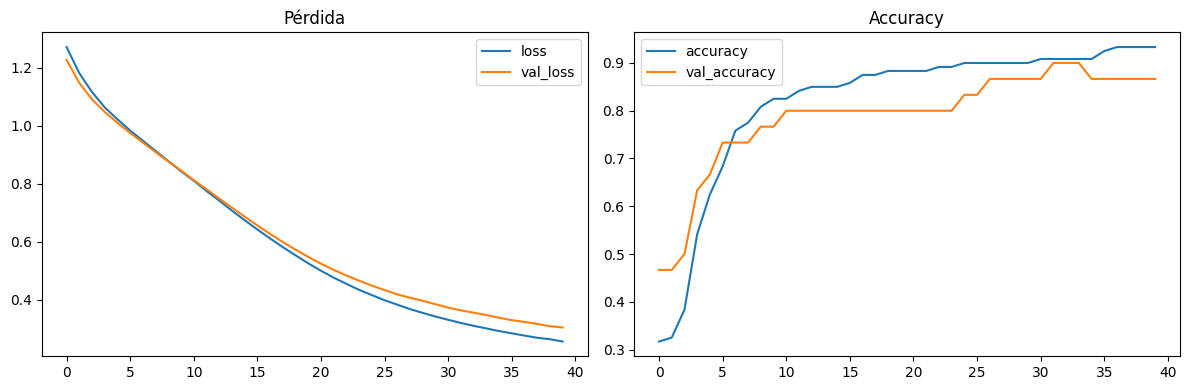

In [11]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Pérdida")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## 11. Probar una predicción individual


In [12]:
idx = 0
muestra = X_val[idx:idx+1]
pred = model.predict(muestra)
clase_pred = np.argmax(pred, axis=1)[0]
clase_real = y_val[idx]

print("Clase real:", data.target_names[clase_real])
print("Clase predicha:", data.target_names[clase_pred])
print("Probabilidades:", pred[0])



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Clase real: setosa
Clase predicha: setosa
Probabilidades: [9.9660057e-01 3.1757159e-03 2.2373248e-04]


## 12. Búsqueda de hiperparámetros: GrisSearchCV y RandomizedSearchCV

In [13]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

# 1. Definimos la función constructora del modelo
def build_model(n_hidden=1, n_neurons=16, learning_rate=0.001):
    model = keras.Sequential()
    model.add(keras.Input(shape=(X_train.shape[1],)))

    # Capas ocultas dinámicas según la búsqueda
    for _ in range(n_hidden):
        model.add(layers.Dense(n_neurons, activation="relu"))

    # Capa de salida (3 clases)
    model.add(layers.Dense(3, activation="softmax"))

    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

# 2. Creamos el wrapper de SciKeras
model_wrapper = KerasClassifier(model=build_model, verbose=0)

# 3. Espacios de búsqueda
# Para GridSearch (combinaciones totales: 2 * 2 * 2 * 2 = 16)
param_grid = {
    "model__n_hidden": [1, 2],
    "model__n_neurons": [16, 32],
    "batch_size": [16, 32],
    "epochs": [20, 30]
}

# Para RandomizedSearch (más amplio, probará 10 combinaciones al azar)
param_dist = {
    "model__n_hidden": [1, 2, 3],
    "model__n_neurons": [16, 32, 64],
    "model__learning_rate": [0.01, 0.001, 0.0005],
    "batch_size": [16, 32, 64],
    "epochs": [20, 40]
}

In [14]:
# 4. Ejecución de GridSearchCV (Busca TODAS las combinaciones)
grid_search = GridSearchCV(estimator=model_wrapper, param_grid=param_grid, cv=3)
grid_result = grid_search.fit(X_train, y_train)

In [15]:
# 5. Ejecución de RandomizedSearchCV (Busca 10 combinaciones aleatorias)
random_search = RandomizedSearchCV(estimator=model_wrapper, param_distributions=param_dist, n_iter=10, cv=3)
random_result = random_search.fit(X_train, y_train)

In [16]:
# Resultados
print(f"Mejor accuracy Grid: {grid_result.best_score_} \n...usando {grid_result.best_params_}")
print(f"Mejor accuracy Random: {random_result.best_score_} \n...usando {random_result.best_params_}")

Mejor accuracy Grid: 0.9 
...usando {'batch_size': 16, 'epochs': 30, 'model__n_hidden': 2, 'model__n_neurons': 32}
Mejor accuracy Random: 0.9500000000000001 
...usando {'model__n_neurons': 16, 'model__n_hidden': 2, 'model__learning_rate': 0.01, 'epochs': 20, 'batch_size': 64}


In [17]:
# 9. Construir el mejor modelo
best_params = random_result.best_params_

best_model = build_model(
    n_hidden=best_params["model__n_hidden"],
    n_neurons=best_params["model__n_neurons"],
    learning_rate=best_params["model__learning_rate"]
)

# 10. Entrenar el mejor modelo
history = best_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    verbose=1
)

# 11. Evaluar el modelo
loss, accuracy = best_model.evaluate(X_val, y_val, verbose=0)
print("\nLoss en validación:", round(loss, 4))
print("Accuracy en validación:", round(accuracy, 4))

# 12. Predicciones
y_prob = best_model.predict(X_val, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# 13. Matriz de confusión
cm = confusion_matrix(y_val, y_pred)
print("\nMatriz de confusión:")
print(cm)

# 14. Reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(y_val, y_pred, target_names=data.target_names))

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 226ms/step - accuracy: 0.2000 - loss: 1.1187 - val_accuracy: 0.5667 - val_loss: 0.9566
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.5833 - loss: 0.9172 - val_accuracy: 0.6667 - val_loss: 0.8048
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7583 - loss: 0.7604 - val_accuracy: 0.7333 - val_loss: 0.6834
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8083 - loss: 0.6350 - val_accuracy: 0.7333 - val_loss: 0.5924
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.8250 - loss: 0.5422 - val_accuracy: 0.7667 - val_loss: 0.5252
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.8417 - loss: 0.4717 - val_accuracy: 0.8000 - val_loss: 0.4741
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8500 - loss: 0.4186 - val_accuracy: 0.8000 - val_loss: 0.4314
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.8583 - loss: 0.3762 - val_accuracy: 0.8000 - val_loss: 0.3915

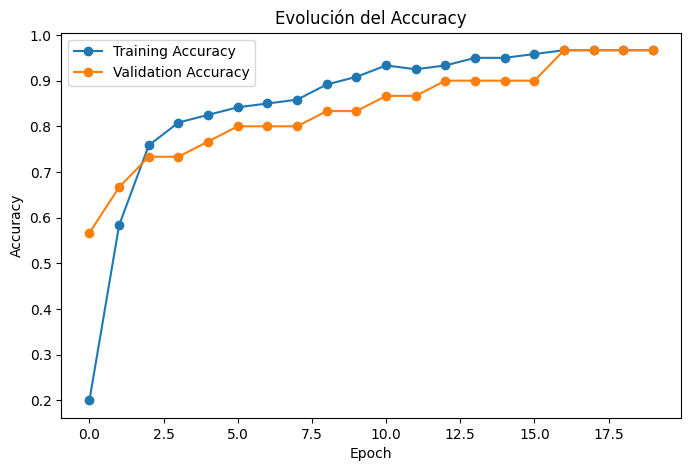

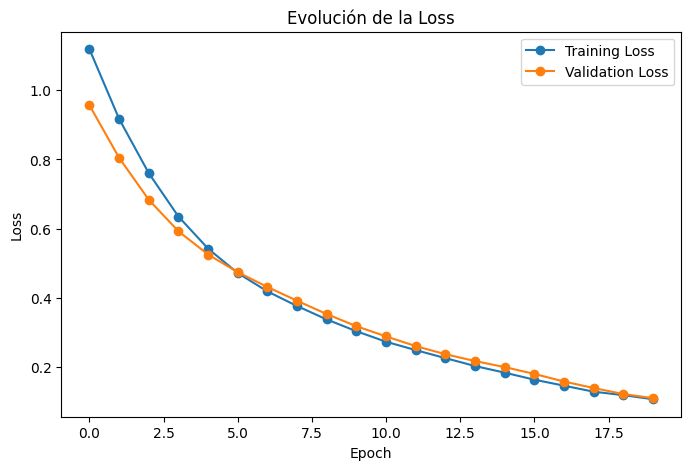


Resumen del mejor modelo:


Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_219 (Dense)               │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_220 (Dense)               │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_221 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,211 (4.73 KB)

 Trainable params: 403 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 808 (3.16 KB)

In [18]:
# 15. Gráfico de accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], marker="o", label="Training Accuracy")
plt.plot(history.history["val_accuracy"], marker="o", label="Validation Accuracy")
plt.title("Evolución del Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 16. Gráfico de loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.plot(history.history["val_loss"], marker="o", label="Validation Loss")
plt.title("Evolución de la Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# 17. Resumen del modelo
print("\nResumen del mejor modelo:")
best_model.summary()

## 13. Análisis Visual de Errores del Modelo Base

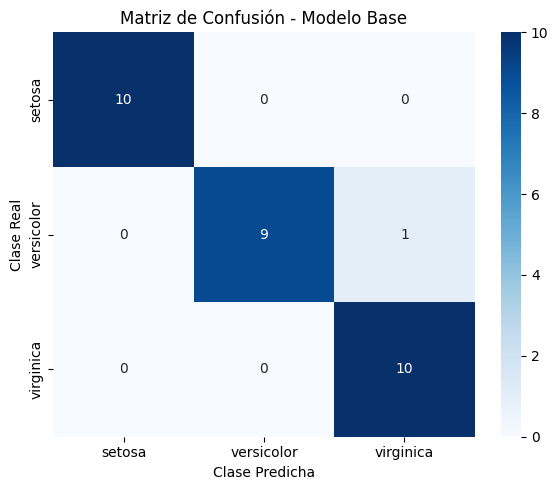

In [19]:
import seaborn as sns

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=data.target_names,
            yticklabels=data.target_names)
plt.title("Matriz de Confusión - Modelo Base")
plt.ylabel("Clase Real")
plt.xlabel("Clase Predicha")
plt.tight_layout()
plt.show()

## 14. Comparación: Modelo Base vs Modelo Optimizado

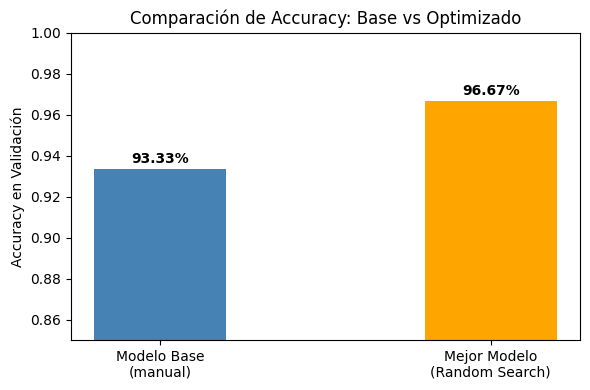

In [20]:
modelos = ["Modelo Base\n(manual)", "Mejor Modelo\n(Random Search)"]
accuracies = [0.9333, 0.9667]
colores = ['steelblue', 'orange']

plt.figure(figsize=(6, 4))
barras = plt.bar(modelos, accuracies, color=colores, width=0.4)
plt.ylim(0.85, 1.0)
plt.title("Comparación de Accuracy: Base vs Optimizado")
plt.ylabel("Accuracy en Validación")

# Etiquetas encima de cada barra
for barra, acc in zip(barras, accuracies):
    plt.text(barra.get_x() + barra.get_width()/2,
             acc + 0.003,
             f"{acc:.2%}",
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()